# **Assignment 3: Introduction to Deep Learning for Sound Event Classification**
### Due: Thursday, March 12th, midnight EST
### Quiz date: Tuesday, March 17th in-class

CS-GY 6933: Machine Listening Spring 2026

Below you will find a mix of coding questions and writing questions to familiarize you with the fundamentals of signal processing in Python.

The assignment will have two parts:

1. Part 0: **Tutorial**: getting used to working with PyTorch (tensors, data loading, training and evaluating a simple model). This portion is not worth any points and typically will not have anything to "fill-in". I recommend you walk through the code and run it to understand the pieces before moving on if you are new to this material.

2. Parts 1-3: **Problem solving**: MFCC feature design (2pts), and model design for sound event classification (3pts). Totaling 5 points. The in-class quiz about the assignment will also be worth 5 points. There is also 1 point of extra credit available in this section!⭐


**A note on GPU Colab credits:** we can get a free student Pro membership to Colab that has 100 compute credits per month. Using an L4 GPU will get you plenty fast performance for these experiments and only uses 1.71 credits per hour (though don't turn to GPU runtime until the model training to save credits).


When you complete the assignment, please evaluate the notebook so that all results are shown/printed before submitting via Brightspace.



🚨 Please refrain from using ChatGPT etc. to fully write the code for this assignment. You will need to understand the content to succeed in the in-class quiz.

# Part 0: PyTorch fundamentals [0pts]
We'll be using PyTorch in this course for deep learning! In this section we will walk through some basics of Torch, setting up a dataset/"dataloader", and a general template for training a model. For more tutorials on PyTorch basics, check out the Torch website [here](https://pytorch.org/tutorials/beginner/basics/intro.html).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
!pip install torchinfo

In [3]:
from torchinfo import summary

### PyTorch Tensors
Tensors are the core data type you will work with in PyTorch. PyTorch tensors and NumPy arrays are both multi-dimensional data structures used for numerical computations, but tensors are optimized for GPU acceleration and support automatic differentiation (autograd), making them ideal for deep learning. NumPy arrays are primarily CPU-based and lack built-in support for gradients. Check out some examples of tensor manipulations below:

In [4]:
# Creating a Tensor (like a NumPy array but with GPU support)
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])  # 2x2 matrix
print(x)

# Creating a Random Tensor
rand_tensor = torch.rand(3, 3)  # 3x3 matrix with random values
print(rand_tensor)

# Basic Tensor Operations
y = x + 2  # Element-wise addition
z = x * y  # Element-wise multiplication
print("Added Tensor:\n", y)
print("Multiplied Tensor:\n", z)

# Moving Tensors to GPU (if available)
device = "cuda" if torch.cuda.is_available() else "cpu" # You may see this line of code at the top of all
x_gpu = x.to(device)  # Moves tensor to GPU
print("Tensor on device:", x_gpu.device)

# Reshaping a Tensor
reshaped = x.view(4, 1)  # Reshape to 4x1
print("Reshaped Tensor:\n", reshaped)

# Converting Between NumPy and Torch
numpy_array = x.numpy()  # Convert to NumPy
torch_tensor = torch.from_numpy(numpy_array)  # Convert back to PyTorch tensor

tensor([[1., 2.],
        [3., 4.]])
tensor([[0.2553, 0.9332, 0.8472],
        [0.1810, 0.2278, 0.9870],
        [0.9880, 0.3836, 0.1368]])
Added Tensor:
 tensor([[3., 4.],
        [5., 6.]])
Multiplied Tensor:
 tensor([[ 3.,  8.],
        [15., 24.]])
Tensor on device: cpu
Reshaped Tensor:
 tensor([[1.],
        [2.],
        [3.],
        [4.]])


### Datasets and dataloaders
In PyTorch, we often work with iterable datasets, which are wrapped in a dataloader class. This provides a nice way to iterate through our data as we train our model. See the docs for more info here.

Below I've provided a very simple template dataset and dataloader to give you a framework to build off of as we get into the audio datasets below.

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

# Our simple dataset class
class SimpleDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data  # (ex: numpy array of (n_samples, n_features), list of filepaths etc.)
        self.labels = labels  # (ex: list of class labels)

        print(f'Number of data samples: {len(self.data)}')

    def __len__(self):
        return len(self.data)  # Return dataset size, this is just a formality

    # Get item is the core method that retrieves one sample (and a label, optionally)
    def __getitem__(self, idx):
        # idx is the index into your full dataset (e.g. sample at index 2 from your dataset)
        return self.data[idx], self.labels[idx]  # Return sample and label


In [6]:
# Dummy data
data = torch.randn(100, 10)  # 100 samples, each with 10 features
labels = torch.randint(0, 2, (100,))  # 100 binary labels

# Create dataset and DataLoader
dataset = SimpleDataset(data, labels)

# Dataloader is an iterable wrapper class for dataset
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Iterate over DataLoader
for batch in dataloader:
    inputs, targets = batch
    print(inputs.shape, targets.shape)
    break  # Stop after first batch for demo

# Note that if you are using different train/val/test splits, usually
# you create separate dataset instances+dataloaders for each of the splits

Number of data samples: 100
torch.Size([4, 10]) torch.Size([4])


### Model definition
Below we define a simple single-layer model class in PyTorch. Read through the comments to understandn the __init__ and forward() functionalities. Note that the weights and biases of your model layers are "under the hood" below - we won't be explicitly defining them here.

In [7]:
class SimpleModel(nn.Module):
    def __init__(self, input_channels, n_classes):
        super(SimpleModel, self).__init__() # formality
        # Here we define the model architecture
        # This *doesn't* tell us how data flows through the model, just the architecture

        # Define one single linear layer
        # This has to accept 2-dim input and return n_classes output
        # Input should be (batch_size, input_channels)
        # Linear layer operates on channel dimension only
        self.fc = nn.Linear(input_channels, n_classes)

    # The forward pass is the core method in a model class
    # This determines how data x flows through the network
    def forward(self, x):
        output = self.fc(x)
        return output

In [8]:
# Simple function to get the model config and number of parameters
def print_model(model):
    # Print model's state_dict
    print("Model's state dictionary (stored weights):")
    for param_tensor in model.state_dict():
        print("  ", param_tensor, "\t", tuple(model.state_dict()[param_tensor].size()))

    # Print the number of parameters in the model
    parameter_count =  sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("In total, this network has ", parameter_count, " trainable parameters")


In [9]:
print_model(SimpleModel(input_channels=2, n_classes=10))

Model's state dictionary (stored weights):
   fc.weight 	 (10, 2)
   fc.bias 	 (10,)
In total, this network has  30  trainable parameters


In [10]:
# Let's test out passing some dummy data through the model
# This is only a *forward* pass through the model e.g. "inference" - not training or doing any back propogation
model = SimpleModel(input_channels=2, n_classes=5)
sample_data = torch.randn(10,2)
output = model(sample_data)
print(output.shape)

torch.Size([10, 5])


### Backpropogation and optimization in pytorch
In neural networks, the model will learn to map inputs through intermediate ("hidden") representations of varying dimensions. This complexity helps our model learn more complex mapping functions, but adds a level of difficulty in figuring out how to update the weights of all of our parameters of the model (e.g. with gradient descent!).

To update our network given a target and predicted output, we will compute the loss (e.g. mean-squared error) using a differentiable loss function, and then compute the gradient of the loss function with respect to each model weight, and performing a small update in the opposite direction of the gradient. The computation of these gradients is called backpropagation, and allows us to systematically train large and complex neural networks.

Luckily, PyTorch provides automatic differentiation (e.g. autograd), which provides a built-in gradient computation for us! Let's play with a few aspects of gradients in PyTorch before incorporating the model component.

In [11]:
# Note that below, we aren't actually doing any "model training"
# This shows how we would do manual optimization - without using built-in optimization yet.

# Sample tensor
x = torch.ones(5)
print(f"Creating a tensor of type {type(x)} with shape {x.shape}")
print(f"Starting x: {x}")

# During backpropagation, gradients will only be computed for tensors with the
# `requires_grad` attribute set to True. We can set this manually if need be
print(f"Does our tensor require gradient computation? {x.requires_grad}")
x.requires_grad = True
print(f"Does our tensor require gradient computation? {x.requires_grad}")

# To perform backpropagation, we need to complete a "forward pass" in which
# computations are performed on Tensor objects to compute a scalar loss value
# This is just a dummy scalar loss function - in practice this will
loss = 10 - x.sum()
print(f"Starting `loss` value: {loss}")
print(f"Gradients of x: {x.grad}") # no gradients yet
print(f"Loss function requires_grad?: {loss.requires_grad}")

# PyTorch will compute all required gradients for tensors involved in the
# computation of a scalar loss value once we call `.backward()`
loss.backward()
print(f"Gradients of x: {x.grad}")

# We can manually update our `weights` in the opposite direction of this gradient
# to reduce our loss value!
x = x - x.grad
print(f"Updated x: {x.data}")
loss = 10 - x.sum()
print(f"Updated `loss` value: {loss}")

Creating a tensor of type <class 'torch.Tensor'> with shape torch.Size([5])
Starting x: tensor([1., 1., 1., 1., 1.])
Does our tensor require gradient computation? False
Does our tensor require gradient computation? True
Starting `loss` value: 5.0
Gradients of x: None
Loss function requires_grad?: True
Gradients of x: tensor([-1., -1., -1., -1., -1.])
Updated x: tensor([2., 2., 2., 2., 2.])
Updated `loss` value: 0.0


n the above example we computed differentiable a scalar loss, used backpropagation to compute the gradients of the loss with respect to our "weights," and performed a gradient-based update on our weights to reduce the loss. Rather than managing the weight-update process by hand, we can defer to a built-in optimizer object that automatically adjusts weights based on stored gradients and standard hyperparameters (e.g. learning rate). When training neural networks with large numbers of parameters, this becomes much simpler than manually updating each weight. ([Credit](https://github.com/interactiveaudiolab/course-deep-learning/blob/main/notebooks/notebook_2_nn.ipynb))

In [12]:
# Repeat our simple optimization, this time using the optimizer.
x = torch.ones(5).requires_grad_(True)
print(f"Starting x: {x}")

# Create an optimizer object and pass it an Iterable containing our "weights".
# Here, SGD is the torch stochastic gradient descent optimizer.
# It has been handed our tensor x as something to optimize and the learning rate
# (lr) is set to 1, which determines the step size for making changes to x.
# Note that this example learning rate is very high! in practice we usually use something like 0.1 or 0.01.
opt = torch.optim.SGD([x], lr = 1.0)

# Compute loss and perform backpropagation.
loss = 10 - x.sum()
loss.backward()

# perform an automatic optimization step, i.e. a gradient-based update of our weights
opt.step()

print(f"Updated x: {x}")

Starting x: tensor([1., 1., 1., 1., 1.], requires_grad=True)
Updated x: tensor([2., 2., 2., 2., 2.], requires_grad=True)


### Simple training pipeline
Finally, let's put all of the pieces together and write a simple training script for a dummy classification task.

In [13]:
# Data setup
train_data = torch.randn(100, 10, dtype=torch.float32)  # 100 samples, each with 10 features
train_labels = torch.randint(0, 5, (100,))  # 100 labels between 0-4

# Create dataset and DataLoader
train_dataset = SimpleDataset(train_data, train_labels)

# Dataloader is an iterable wrapper class for dataset
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Also create the validation dataloader
val_data = torch.randn(20, 10, dtype=torch.float32)
val_labels = torch.randint(0, 5, (20,))
val_dataset = SimpleDataset(val_data, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Model setup
model = SimpleModel(input_channels=10, n_classes=5)

# Optimizer setup, on all of our model parameters
opt = torch.optim.SGD(model.parameters(), lr = 0.01)

# Define the loss function
loss_fn = nn.CrossEntropyLoss().to(device)


# This tells your model that you are in training mode and not testing mode
# For our simple case this doesn't do much, but more complex layers such as Dropout
# behave differently in training vs. evaluation mode
model.train()


# TRAINING LOOP

# Loop through the entire [training] data each "epoch"
# So you will go through every "batch" of data inside this epoch
epochs = 10
for epoch in range(epochs):
    total_loss = 0.0
    for batch in train_dataloader:
        inputs, targets = batch
        # Set the gradients to 0 before running the network on the data each iteration, so that
        # loss gradients can be computed correctly during backpropagation
        opt.zero_grad()
        # print(f"Model input shape (batch): {inputs.shape}")

        # Get the output of the network on the data
        # Note that these are probabilities, *not* class labels!
        output = model(inputs)
        # print(f"Model output shape (batch): {output.shape}")

        # Measure the "loss" using mean squared error
        loss = loss_fn(output, targets)

        # This calculates the gradients, performing backpropagation to propagate
        # errors backward through the network's weights
        loss.backward()

        # This updates the network weights based on the freshly-computed gradient
        # now stored alongside each weight
        opt.step()

        # Accumulate the total loss per epoch
        total_loss += loss.item()

    print(f"Training Epoch {epoch+1}/{epochs}, Train Loss: {total_loss / len(dataloader):.4f}")

    # VALIDATION LOOP
    # The validation loop
    model.eval()
    total_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # Disable gradient computation
        for batch in val_dataloader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            total_val_loss += loss.item()

            # Compute validation accuracy
            _, predicted = torch.max(outputs, dim=1)
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = correct_val / total_val

    # Print results
    print(f"Validation Epoch {epoch+1}/{epochs}, Val: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}\n")


Number of data samples: 100
Number of data samples: 20
Training Epoch 1/10, Train Loss: 1.7415
Validation Epoch 1/10, Val: 1.6590, Val Accuracy: 0.3500

Training Epoch 2/10, Train Loss: 1.7108
Validation Epoch 2/10, Val: 1.6515, Val Accuracy: 0.2500

Training Epoch 3/10, Train Loss: 1.6826
Validation Epoch 3/10, Val: 1.6455, Val Accuracy: 0.2500

Training Epoch 4/10, Train Loss: 1.6567
Validation Epoch 4/10, Val: 1.6411, Val Accuracy: 0.2500

Training Epoch 5/10, Train Loss: 1.6337
Validation Epoch 5/10, Val: 1.6378, Val Accuracy: 0.2500

Training Epoch 6/10, Train Loss: 1.6129
Validation Epoch 6/10, Val: 1.6356, Val Accuracy: 0.2500

Training Epoch 7/10, Train Loss: 1.5930
Validation Epoch 7/10, Val: 1.6344, Val Accuracy: 0.2500

Training Epoch 8/10, Train Loss: 1.5766
Validation Epoch 8/10, Val: 1.6340, Val Accuracy: 0.2500

Training Epoch 9/10, Train Loss: 1.5614
Validation Epoch 9/10, Val: 1.6344, Val Accuracy: 0.2500

Training Epoch 10/10, Train Loss: 1.5463
Validation Epoch 10/10

### Model evaluation
Now that we've "trained" our dummy model, let's walk set up the evaluation script. Note that typically you will have a training and validation loop, which run in sequence for N epochs, and once you have the final trained model, then you will do the final evaluation on the test set separately - similar to what we did with cross validation in assignment 2. But for this demo, we'll just do the training above and then use that trained model for a fake test loop.

In [14]:
# Create dataset and DataLoader
test_data = torch.randn(20, 10, dtype=torch.float32)
test_labels = torch.randint(0, 5, (20,))
test_dataset = SimpleDataset(test_data, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=True)

# Switch model to eval mode (IMPORTANT!)
model.eval()  # Set the model to evaluation mode

num_correct = 0

# Explicitly stop gradient computation here
with torch.no_grad():
    for batch in test_dataloader:
        inputs, targets = batch
        output = model(inputs)

        # Here we don't care as much about the loss (though you can still compute it)
        # Convert the output logits to class probabilities
        # Why didn't we do this argmax in training? CrossEntropy loss under the hood uses softmax :)
        predictions = torch.argmax(output, dim=-1)
        num_correct += (predictions == targets).sum().item()  # Count correct predictions

print(f"Test Accuracy: {num_correct / len(test_dataset)}")


Number of data samples: 20
Test Accuracy: 0.1


⚔️⚔️⚔️ Awesome! You are now equipped with the basic tools needed to start training real deep learning models! ⚔️⚔️⚔️

# Part 1: MFCC Feature Design [2pts]
In this section you'll be building an MFCC feature extractor as we discussed in class. You'll use this feature later in model training. Before we get into the details, first let's explore the dataset we'll be using in this assignment.

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
from scipy.fft import dct, idct

### Data
We'll be using **ESC-50**, a popular dataset for environmental sound classification, for this assignment. The dataset has 2000 x 5-second environmental sound recordings across 50 classes. You can read more about the dataset [here](https://github.com/karolpiczak/ESC-50).

In [16]:
# TODO: Run this code to download and unzip the dataset. It is about 600 MB
# Download ESC-50 master zip. The zip file is about 600MB (should take ~2 min to run this cell)

!curl -L -o master.zip https://github.com/karoldvl/ESC-50/archive/master.zip
!unzip -q master.zip
!rm -rf ESC50
!mv ESC-50-master ESC50
!rm -f master.zip

print("Done!")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.6M    0 18.6M    0     0  11.1M      0 --:--:--  0:00:01 --:--:-- 13.6M

OSError: [Errno 5] Input/output error

#### 🔎 But first: check out the data 🔎
It's always a good first step to explore a new dataset and make sure the input data is in a format you're expecting.

**Deliverables:**
1. Load an audio file from ESC-50 (in the audio directory) with the default sample rate.
2. Plot the waveform.
3. Plot the log mel spectrogram (use `librosa`).
4. Play the audio.
5. Load the full metadata csv (in `esc50.csv`), locate the sample you're examining, and confirm that your label matches what you're expecting, and what you see in the spectrogram.


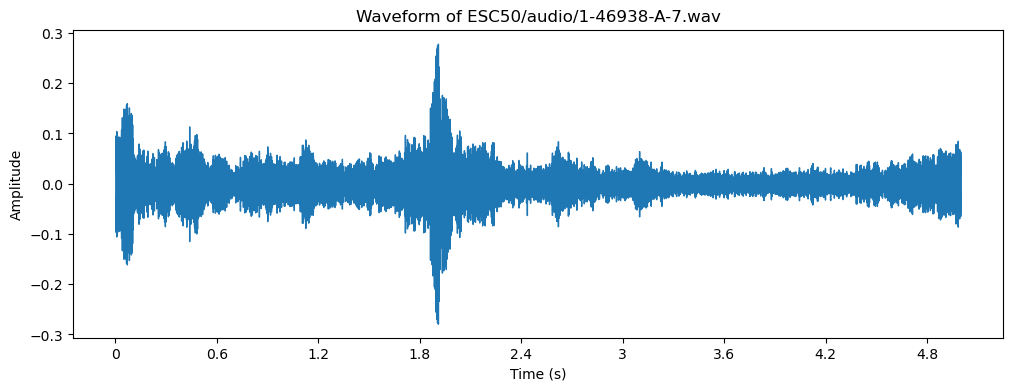

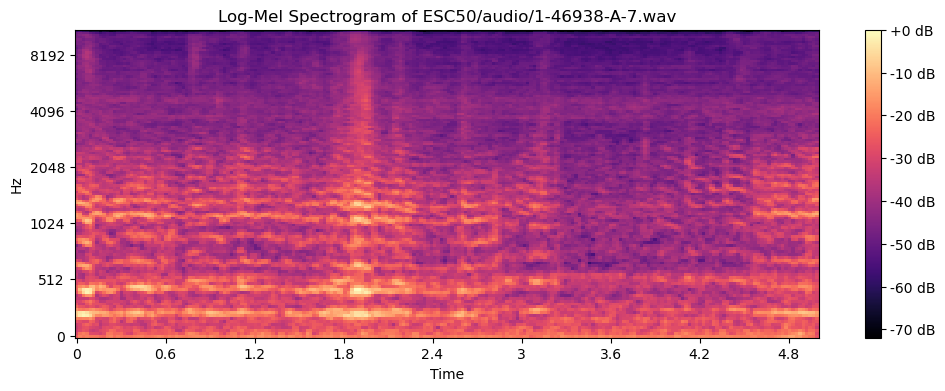

,filename,fold,target,category,esc10,src_file,take
221,1-46938-A-7.wav,1,7,insects,False,46938,A


In [17]:
# 🚨TODO🚨

#1: Load audio file
file_path = "ESC50/audio/1-46938-A-7.wav"
y, sr = librosa.load(file_path)  # y = waveform, sr = sampling rate (22050 is default)

#2: Plot waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of " + file_path)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

#3: Plot log mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128) # Mel spectrogram
S_db = librosa.power_to_db(S, ref=np.max) # Convert power spectrogram to log scale (dB)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram of " + file_path)
plt.show()

#4: Play audio
display(Audio(y, rate=sr))

#5: Metadata CSV Validation
filename = file_path.split("/")[-1] # take last section of file name
meta = pd.read_csv("ESC50/meta/esc50.csv") # Load metadata
row = meta[meta["filename"] == filename] # Find the matching row
row



#### Quick check: class distribution
Before we move on, let's also look at some aggregate statistics about the classes in the dataset:

**Deliverables**:
1. Print the number of files total.
2. Print the number of classes total.
3. Plot the number of files per class in a bar chart. For your own understanding: are the classes balanced? Unbalanced?

Number of files: 2000
Number of classes: 50


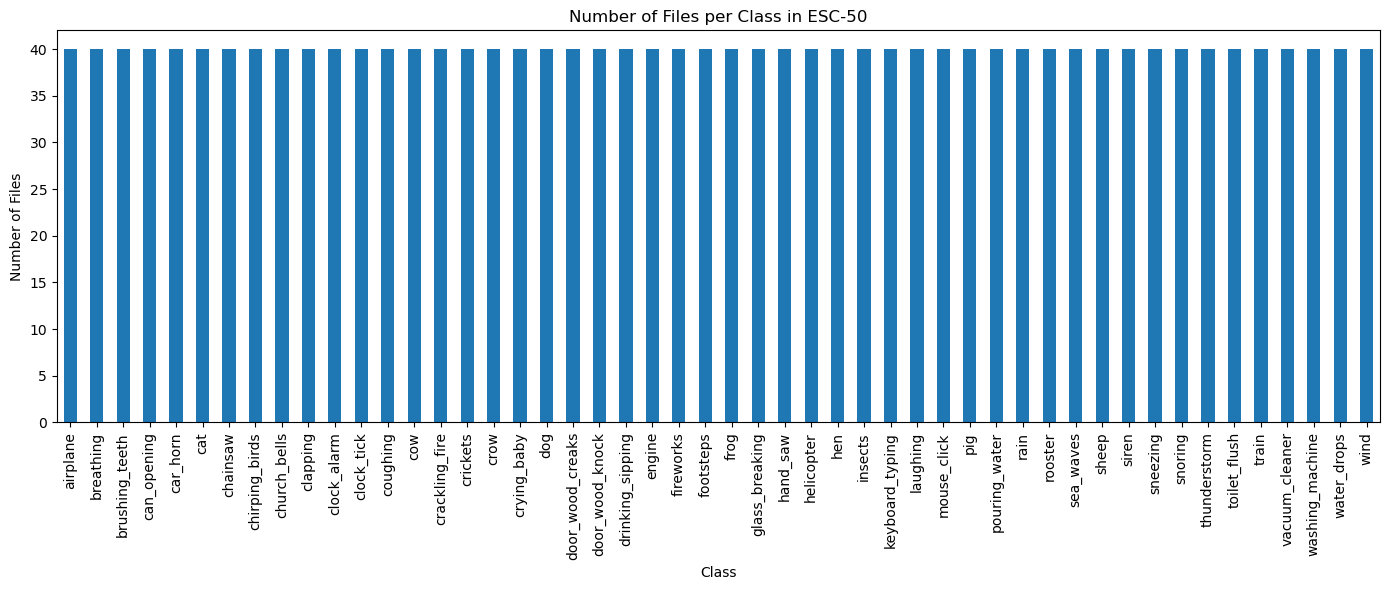

It is clear from this bar-chart that the classes are perfectly balanced.


In [18]:
# 🚨TODO🚨
# 1: Number of files total
num_files = len(meta)
print("Number of files:", num_files)

# 2: Number of classes total
num_classes = meta["category"].nunique()
print("Number of classes:", num_classes)

# 3: Number of files per class
class_counts = meta["category"].value_counts().sort_index()

plt.figure(figsize=(14, 6))
class_counts.plot(kind="bar")
plt.title("Number of Files per Class in ESC-50")
plt.xlabel("Class")
plt.ylabel("Number of Files")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("It is clear from this bar-chart that the classes are perfectly balanced.")

### Designing MFCC features [1pt]
**Deliverables**

- Implement an MFCC feature extraction method as discussed in class.
    - You may ***not*** use librosa's built in MFCC method for this.
    - You ***may*** use numpy or scipy built-in methods as helper functions, and you can use the MelSpectrogram method from librosa.
- Using an ESC-50 audio file, plot the log-mel Spectrogram and MFCCs of this signal using your method. The MFCC plot should contain time on the x-axis and coefficient index on y-axis.


In [20]:
def get_mfcc_features(mel_spec, m=None):
    """ Compute MFCC features from a mel spectrogram.
    Always drop the first 2 coefficients, and use `m`
    to decide how many remaining coefficients to keep after those are dropped.
    i.e., keep up to coefficient `m` (index m+2 before dropping [0-1]

    Tips:
    - Use DCT-Type II
    - Include norm="ortho" in your DCT method call for normalization.

    Parameters
    ----------
    mel_spec : np.ndarray, shape (n_mels, n_frames)
        Mel spectrogram (in power).
    m: Discard cepstral coefficients beyond this index m.

    Returns
    -------
    mfcc : np.ndarray, shape (n_mfcc, n_frames)
        Matrix of retained MFCC features.

    Returns:
      - mfcc_trunc: (m, n_frames) MFCC features, with appropriate coefficients dropped.
      - mfcc_trunc_full:(n_mels, n_frames) same information as mfcc_trunc, but of the original length.
        (dropped coefficients zeroed, that we'll use for envelope plots)
      - mel_db: (n_mels, n_frames) log-mel spectrogram
    """

    # Step 1: Convert mel spectrogram (power) to log scale (dB)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)  # shape: (n_mels, n_frames)

    # Step 2: Apply DCT-II along the frequency axis (axis=0) to get cepstral coefficients
    mel_spec_dct = scipy.fft.dct(mel_db, type=2, norm="ortho", axis=0)  # shape: (n_mels, n_frames)

    # Step 3: Determine how many coefficients to keep
    n_mels = mel_spec_dct.shape[0]
    if m is None:
        m = n_mels - 2  # keep all after dropping first 2

    # Step 4: Drop coefficients 0 and 1, keep coefficients 2 through m+1 (inclusive)
    mfcc_trunc = mel_spec_dct[2:m + 2]  # shape: (m, n_frames)

    # Step 5: Build full-length version with dropped coefficients zeroed out
    mfcc_trunc_full = np.zeros_like(mel_spec_dct)
    mfcc_trunc_full[2:m + 2] = mfcc_trunc  # shape: (n_mels, n_frames)

    return mfcc_trunc, mfcc_trunc_full, mel_db

In [21]:
# 🚨TODO🚨
# Code to test and plot your MFCC method
# Use these default parameters:

import librosa
import scipy

n_fft = 4096
window_length = 2048
hop_length = 1024
n_mels = 128
sr = 22050
fmin = 200
fmax = 8000

# Load Audio File
y, sr = librosa.load("ESC50/audio/1-137-A-32.wav", sr=sr)

# Convert to melspectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, win_length=window_length, hop_length=hop_length, fmin=fmin, fmax=fmax)

# Pass melspectrogtam into MFCC function
mfcc_trunc, mfcc_trunc_full, mel_db = get_mfcc_features(mel_spectrogram)

# Print shapes for validation
print(mfcc_trunc.shape)
print(mfcc_trunc_full.shape)
print(mel_db.shape)

(126, 108)
(128, 108)
(128, 108)


### Understanding MFCC: plotting the spectral envelope [1pt]
**Deliverables:**

To get a better understanding of the effect of MFCC transformation, create the following sequence of plots, for the audio file **ESC50/audio/5-198411-A-20.wav**:
1. Log Mel spectrogram
2. MFCC
3. Spectral envelope: log mel *spectrum* and reconstructed spectrum from your MFCCs, both at frame 54, overlayed on the same plot. Show 4 versions of this plot, for `m={5,10,12,40}` in your MFCC function to observe the effect.

**Guidelines and tips:**
- Take care in naming your axis appropriately and ensuring that the scaling of each plot makes sense - we will be looking for this as one aspect of grading here.
- Tip 1: You will want to reconstruct using the full-length MFCCs (containing zero'd coefficients).
- Tip 2: Because the first two coefficients are dropped, your enevelope may appear DC-shifted when reconstructed. To get around this you can add the mean of the log mel spectrogram back to the reconstructed spectrum

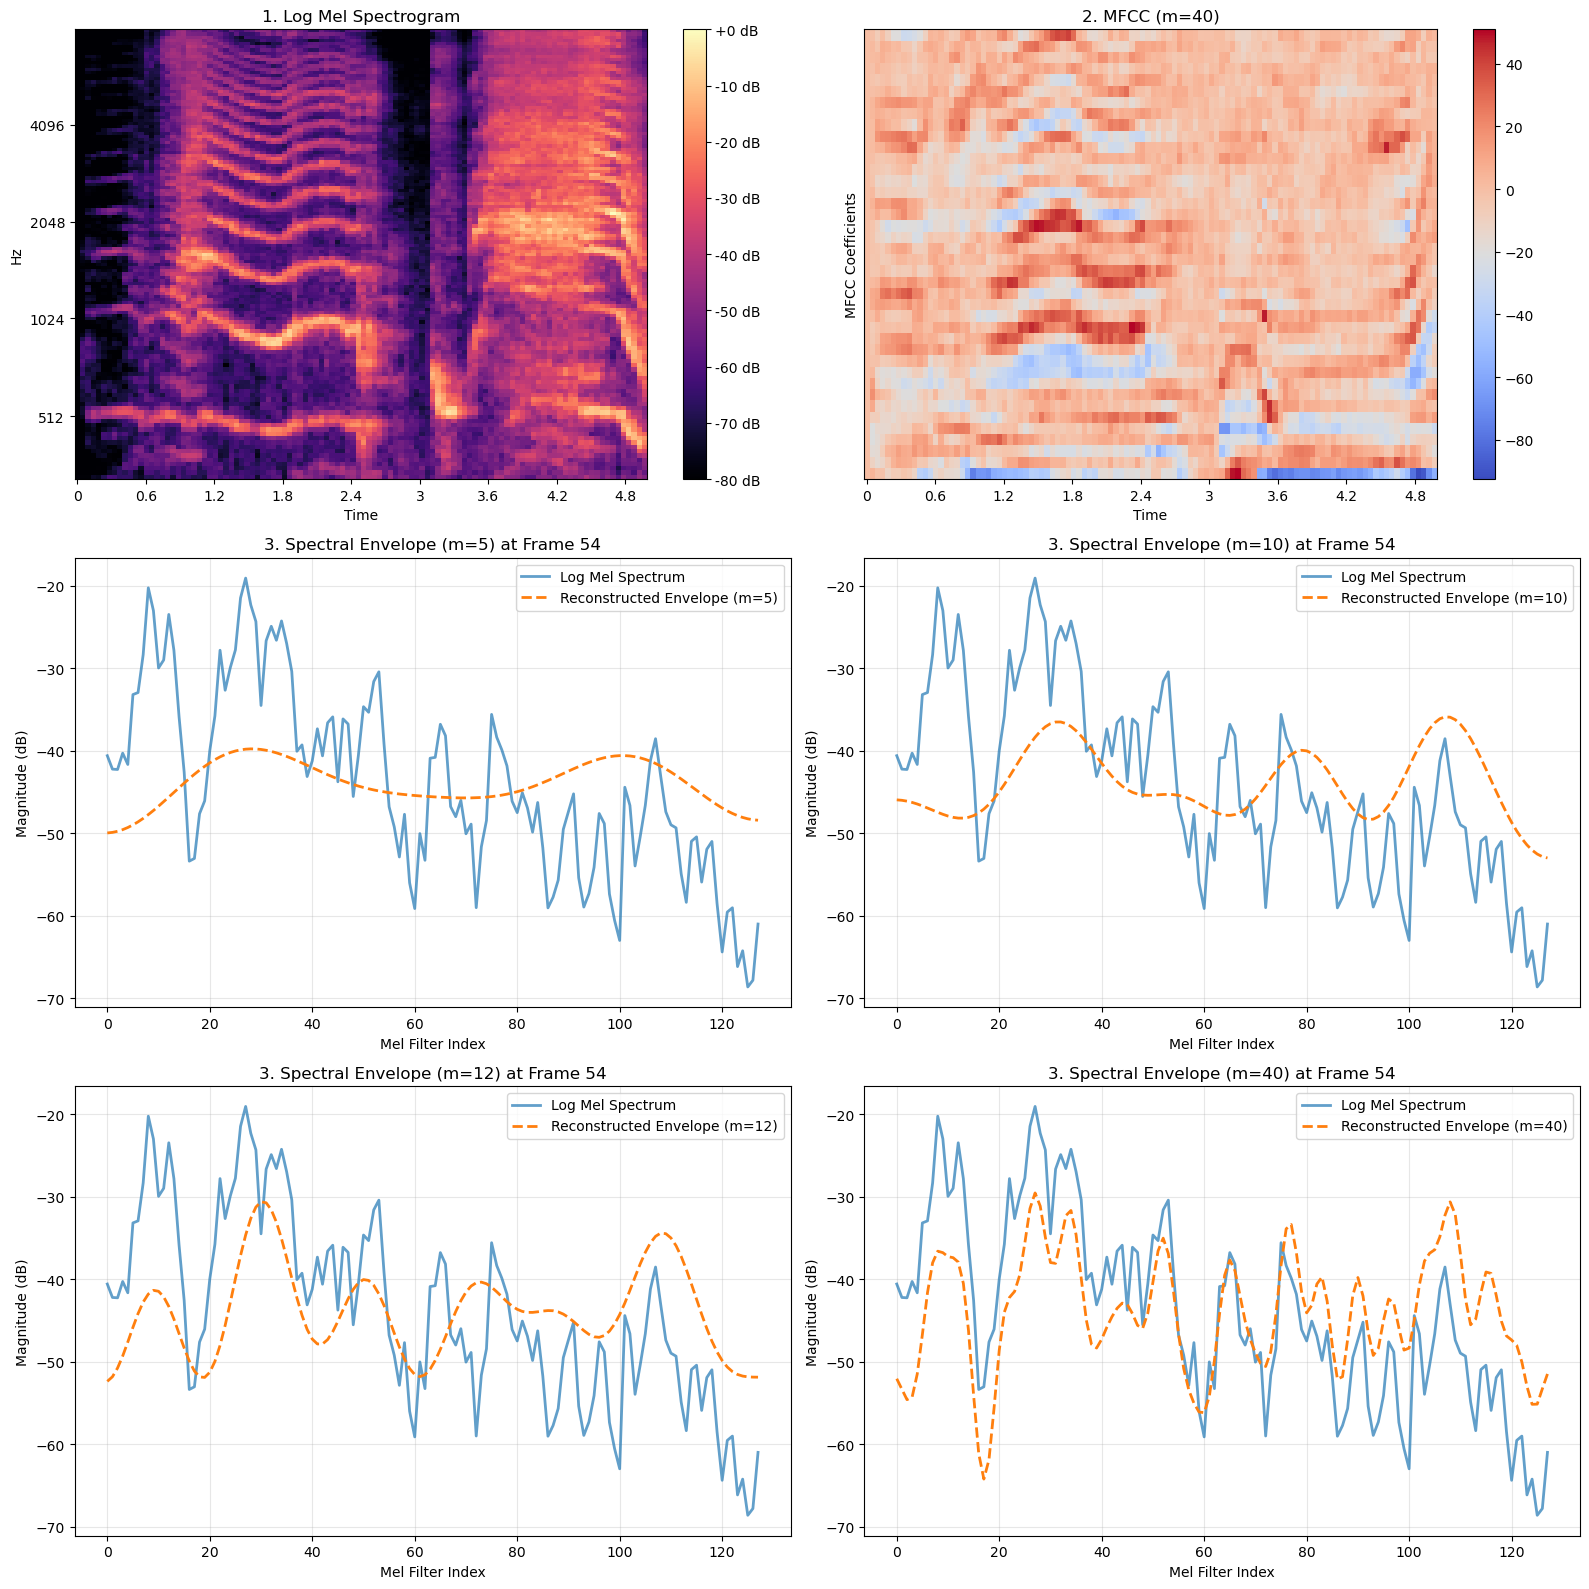

In [22]:
# Use these default parameters
n_fft = 4096
window_length = 2048
hop_length = 1024
n_mels = 128
sr = 22050
fmin = 200
fmax = 8000

# 1. Load the Audio
y, sr = librosa.load("ESC50/audio/5-198411-A-20.wav", sr=sr)

# 2. Compute the Mel Spectrogram
# (Note: Using win_length=window_length to avoid the librosa TypeError)
mel_spectrogram = librosa.feature.melspectrogram(
    y=y, sr=sr, n_fft=n_fft, win_length=window_length, 
    hop_length=hop_length, fmin=fmin, fmax=fmax, n_mels=n_mels
)

# 3. Initialize figure with 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

# Get the base MFCC factors to plot the first 2 visualization plots
mfcc_trunc_40, _, mel_db_40 = get_mfcc_features(mel_spectrogram, m=40)

# Plot 1: Log Mel Spectrogram
img1 = librosa.display.specshow(
    mel_db_40, sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', 
    fmin=fmin, fmax=fmax, ax=axes[0]
)
axes[0].set_title('1. Log Mel Spectrogram')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

# Plot 2: MFCC 
img2 = librosa.display.specshow(
    mfcc_trunc_40, sr=sr, hop_length=hop_length, x_axis='time', ax=axes[1]
)
axes[1].set_title('2. MFCC (m=40)')
axes[1].set_ylabel('MFCC Coefficients')
fig.colorbar(img2, ax=axes[1])

# Plot 3-6: Spectral envelope for m={5,10,12,40}
m_values = [5, 10, 12, 40]
frame_idx = 54
for i, m in enumerate(m_values):
    # Obtain features for the current m
    _, mfcc_full, mel_db_m = get_mfcc_features(mel_spectrogram, m=m)
    
    # Reconstruct spectrum using full-length MFCCs via IDCT (Inverse DCT-II is Type-3)
    reconstructed_spec = scipy.fft.idct(mfcc_full, type=2, norm="ortho", axis=0)
    
    # Add the DC offset back (mean of the log mel spectrogram for the frame)
    # This compensates for the fact that we zeroed out the first DCT coefficient (the mean)
    dc_offset = np.mean(mel_db_m[:, frame_idx])
    
    # Extract the target frame data
    original_frame = mel_db_m[:, frame_idx]
    reconstructed_frame = reconstructed_spec[:, frame_idx] + dc_offset
    
    ax = axes[2 + i]
    ax.plot(original_frame, label='Log Mel Spectrum', alpha=0.7, linewidth=2)
    ax.plot(reconstructed_frame, label=f'Reconstructed Envelope (m={m})', linestyle='--', linewidth=2)
    ax.set_title(f'3. Spectral Envelope (m={m}) at Frame {frame_idx}')
    ax.set_xlabel('Mel Filter Index')
    ax.set_ylabel('Magnitude (dB)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Play audio
display(Audio(y, rate=sr))


# Part 2: Sound Event Classification [3 pts + 1 pt extra credit available]
You will design, train, and evaluate three model configurations for sound event classification:

The models:
1. MLP, using MFCC features
2. MLP, using log Mel spectrogram features
3. CNN (**1D**), using log Mel spectrogram features

Extra credit [1pt]:
1. CNN (**2D**), using log Mel spectrogram features. If you are doing the extra credit, follow the deliverables for the prior 3 models here, as well as the written question for full credit.

Some tips on the components of the pipeline you'll need to setup:
- Dataloader for ESC-50, retrieves (MFCC/Mel feature, label) per file. Handles train/validation/test splits by fold specified in ESC metadata.
- Model architecture for each.
- Training and validation pipeline.
- Evaluation given a trained model on the test set.




#### **Deliverables**


**1. Model investigation across features and architectures** [2.5 pts]
- Train the three model configurations above for multi-class sound event classification with ESC-50.
- Report **overall accuracy** of each model and **F1-score** of the top and bottom-3 performing classes per configuration (over 3-fold cross validation).

**2. Explanation of results and parameter choices for each model configuration** [0.5 pts]
- Brief written explanation justifying (1) model design/parameter choices for each of the three configurations, and (2) intuition about model performance. See prompt below for details.

**Guidelines for model design:**
- Final model configurations should be reported using **3-fold cross-validation**, in which 3 train/validation/test splits are chosen at random. ESC-50's metadata file has each audio clip labeled with a fold number already (Fold #1-5). Ideally we would do 5-fold, but let's stick with 3 for the scope of this assignment for computational purposes. Feel free to run individual folds (or smaller scale overfitting-style experiments) for early experimentation.
- This is an exercise in ***careful architecture choices for a simple model*** for the task and features at hand. The focus should be on an intentional and informed choices of layer parameters (e.g. hidden dimensions, pooling, model initialization, etc.)
- Model selection should be in terms of minimum validation loss.
- Your model parameter counts should not exceed 200k.
- You will likely want to use some feature normalization as discussed in class.


Baselines:
- As a reference, I was able to achieve ~20-30.5% test accuracy (depending on test fold) using a 90k parameter simple MLP+MFCC model. I used a learning rate of 1e-3, batch size 16, and trained for 10 epochs.


## 1: Model investigation and reports - 💡YOUR CODE HERE💡
Model configurations:
1. MLP, using MFCC features
2. MLP, using log Mel spectrogram features
3. CNN (**1D**), using log Mel spectrogram features

Cleary report results (refer above for what is required).

In [23]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Dataset Defaults:
n_fft = 4096
window_length = 2048
hop_length = 1024
n_mels = 128
sr = 22050
fmin = 200
fmax = 8000


class ESC50Loader(Dataset):
    def __init__(self, df, base_path, feature_type='mfcc', device='cpu'):
        self.df = df
        self.base_path = base_path
        self.feature_type = feature_type
        self.device = device
        
        # Define cache file path
        cache_file = f"{feature_type}_features_cache.npz"
        
        # 1. Check if we already computed and saved these features!
        if os.path.exists(cache_file):
            print(f"Loading {feature_type.upper()} features from cache '{cache_file}'...")
            cache = np.load(cache_file)
            self.features = cache['features']
            self.labels = cache['labels']
        else:
            # 2. If not, compute them from scratch
            self.features = []
            self.labels = []
            
            print(f"Computing {'Mel Spectrogram' if feature_type == 'mel' else 'MFCC'} features from scratch...")
            for idx, row in self.df.iterrows():
                # Progress tracker for the first run
                if idx % 200 == 0:
                    print(f"  - Processed {idx}/2000 audio files")
                    
                y, sr_local = librosa.load(os.path.join(base_path, row['filename']), sr=22050)
                mel_spec = librosa.feature.melspectrogram(
                    y=y, sr=sr_local, n_fft=n_fft, win_length=window_length, 
                    hop_length=hop_length, fmin=fmin, fmax=fmax, n_mels=n_mels
                )

                # Logic to get correct features for each clip: MFCC or Mel
                # Target ~108 frames expected length for a 5 second clip
                if self.feature_type == 'mfcc':
                    feat, _, _ = get_mfcc_features(mel_spec, m=40)
                else:
                    feat = librosa.power_to_db(mel_spec, ref=np.max)
                
                # Pad or truncate temporal length
                if feat.shape[1] > 108:
                    feat = feat[:, :108]
                elif feat.shape[1] < 108:
                    feat = np.pad(feat, ((0, 0), (0, 108 - feat.shape[1])))
                    
                self.features.append(feat)
                self.labels.append(row['target'])
                
            self.features = np.stack(self.features)
            self.labels = np.array(self.labels)
            
            # Save the newly computed features and labels to disk for next time
            print(f"Saving computed {feature_type.upper()} features to cache '{cache_file}'...")
            np.savez(cache_file, features=self.features, labels=self.labels)
        
        # 3. Standardize features globally over population mean/var
        mean = self.features.mean()
        std = self.features.std() + 1e-8
        self.features = (self.features - mean) / std
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        X = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return X, y

In [24]:
class MLP_MFCC(nn.Module):
    def __init__(self):
        super().__init__()
        # Input features: 40 (mean) + 40 (std) = 80 per MFCC audio clip
        # Total params calculation (including biases):
        # Linear1: 80*1024 + 1024 bias = 81,920 + 1,024 = 82,944
        # BN1: 1024 weights + 1024 biases = 2,048
        # Linear2: 1024*100 + 100 bias = 102,400 + 100 = 102,500
        # BN2: 100 weights + 100 biases = 200
        # Linear3: 100*50 + 50 bias = 5,000 + 50 = 5,050
        # Total params: 82,944 + 2,048 + 102,500 + 200 + 5,050 = 192,742
        
        self.net = nn.Sequential(
            nn.Linear(80, 1024),  # 82,944 params
            nn.BatchNorm1d(1024), # 2,048 params
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 100), # 102,500 params
            nn.BatchNorm1d(100),  # 200 params
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(100, 50)    # 5,050 params
        )
        
    def forward(self, x): 
        # x is (Batch, 40, 108)
        x_mean = x.mean(dim=2)
        x_std = x.std(dim=2)
        x_pooled = torch.cat([x_mean, x_std], dim=1) # Shape: (Batch, 80)
        return self.net(x_pooled)

In [25]:
class MLP_Mel(nn.Module):
    def __init__(self):
        super().__init__()
        # Input features: 128 (mean) + 128 (std) = 256 per log Mel audio clip
        # Total params calculation (including biases):
        # Linear1: 256*512 + 512 bias = 131,072 + 512 = 131,584
        # BN1: 512 weights + 512 biases = 1,024
        # Linear2: 512*80 + 80 bias = 40,960 + 80 = 41,040
        # BN2: 80 weights + 80 biases = 160
        # Linear3: 80*50 + 50 bias = 4,000 + 50 = 4,050
        # Total params: 131,584 + 1,024 + 41,040 + 160 + 4,050 = 177,858
        
        self.net = nn.Sequential(
            nn.Linear(256, 512),  # 131,584 params
            nn.BatchNorm1d(512),  # 1,024 params
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 80),   # 41,040 params
            nn.BatchNorm1d(80),   # 160 params
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(80, 50)     # 4,050 params
        )
        
    def forward(self, x): 
        # x is (Batch, 128, 108)
        x_mean = x.mean(dim=2)
        x_std = x.std(dim=2)
        x_pooled = torch.cat([x_mean, x_std], dim=1) # Shape: (Batch, 256)
        return self.net(x_pooled)

In [29]:
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv1: 128->220, k=3 -> 85,140 params
        # BN1: 220*2 = 440
        # Conv2: 220->160, k=3 -> 105,760
        # BN2: 160*2=320
        # Linear: 160->50 -> 8,050
        # Total params: 85,140+440+105,760+320+8,050 = 199,270
        
        self.net = nn.Sequential(
            nn.Conv1d(128, 220, kernel_size=3, padding=1), # 85,140
            nn.BatchNorm1d(220),                            # 440
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(220, 160, kernel_size=3, padding=1), # 105,760
            nn.BatchNorm1d(160),                            # 320
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(160, 50)                              # 8,050
        )
        
    def forward(self, x):
        return self.net(x)

In [32]:
class CNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        # Deep image processing over spectrograms
        # Total params calculation (including biases):
        # Conv1: 1*32*3*3 + 32 bias = 288 + 32 = 320
        # BN1: 32 weights + 32 biases = 64
        # Conv2: 32*96*3*3 + 96 bias = 27,648 + 96 = 27,744
        # BN2: 96 weights + 96 biases = 192
        # Conv3: 96*160*3*3 + 160 bias = 138,240 + 160 = 138,400
        # BN3: 160 weights + 160 biases = 320
        # Linear: 160*100 + 100 bias = 16,000 + 100 = 16,100
        # Total params: 320+64+27,744+192+138,400+320+16,100 = 183,140
        
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 320 params
            nn.BatchNorm2d(32),                           # 64 params
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 96, kernel_size=3, padding=1), # 27,744 params
            nn.BatchNorm2d(96),                           # 192 params
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(96, 160, kernel_size=3, padding=1),# 138,400 params
            nn.BatchNorm2d(160),                          # 320 params
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),                 # reduces HxW -> 1x1
            
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(160, 100)                           # 16,100 params
        )
        
    def forward(self, x): 
        # Add singleton channel dimension (batch, freq, time) -> (batch, 1, freq, time)
        return self.net(x.unsqueeze(1))

Loading MFCC features from cache 'mfcc_features_cache.npz'...

--- Training/Evaluating MLP_MFCC ---
Fold 1/3
Fold 2/3
Fold 3/3


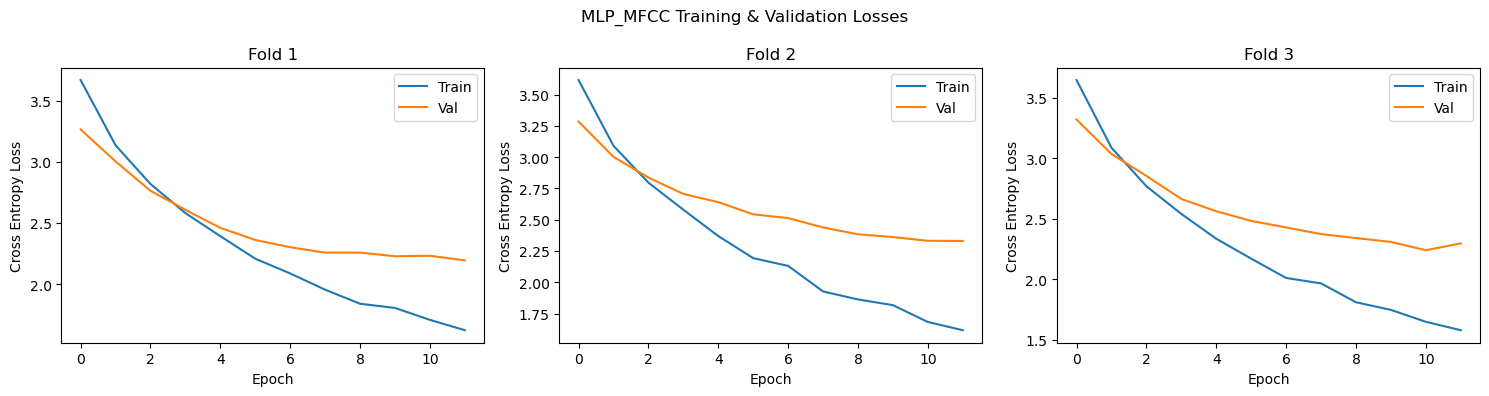

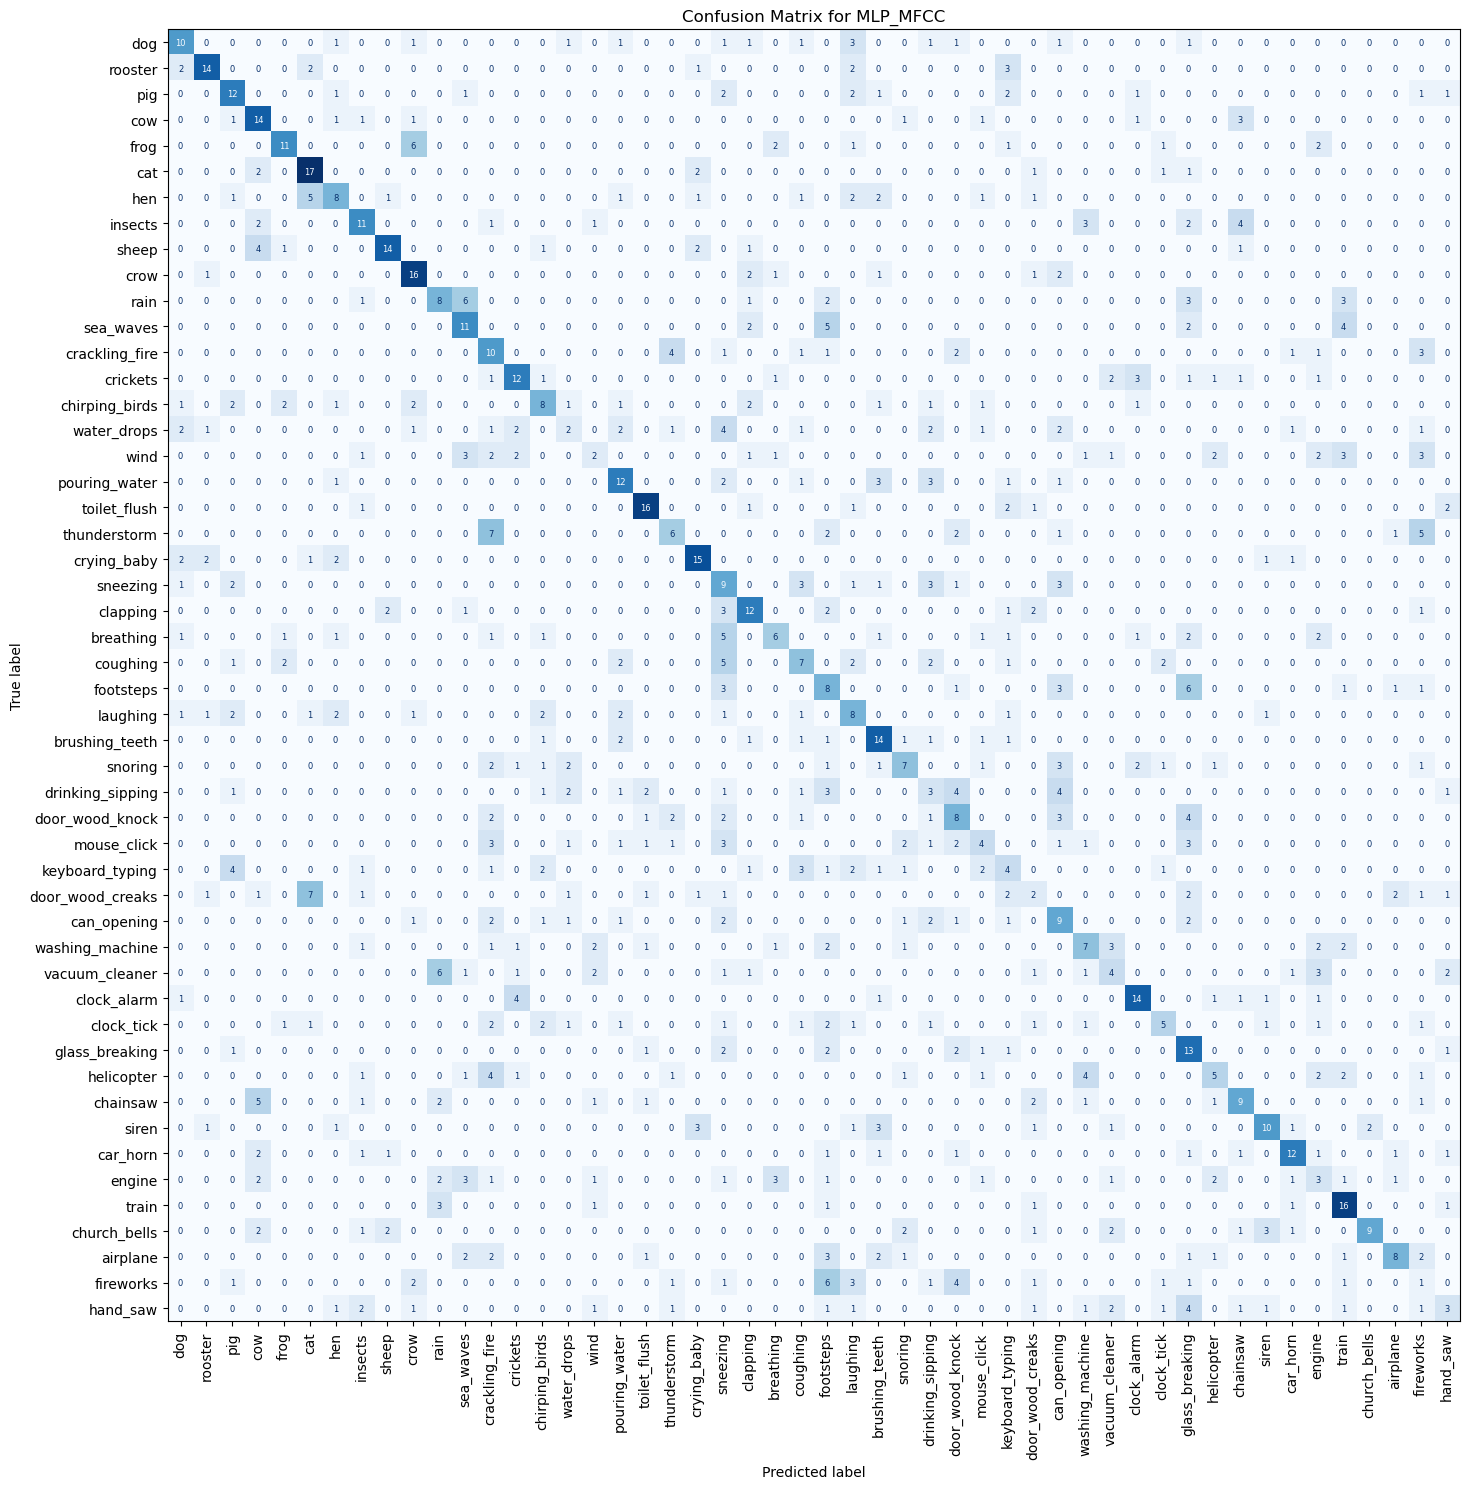

Overall Test Accuracy: 37.42%
Top 3 Classes (F1-Score):
  - toilet_flush: 0.653
  - sheep: 0.636
  - rooster: 0.622
Bottom 3 Classes (F1-Score):
  - fireworks: 0.042
  - door_wood_creaks: 0.098
  - water_drops: 0.111
Loading MEL features from cache 'mel_features_cache.npz'...

--- Training/Evaluating MLP_Mel ---
Fold 1/3
Fold 2/3
Fold 3/3


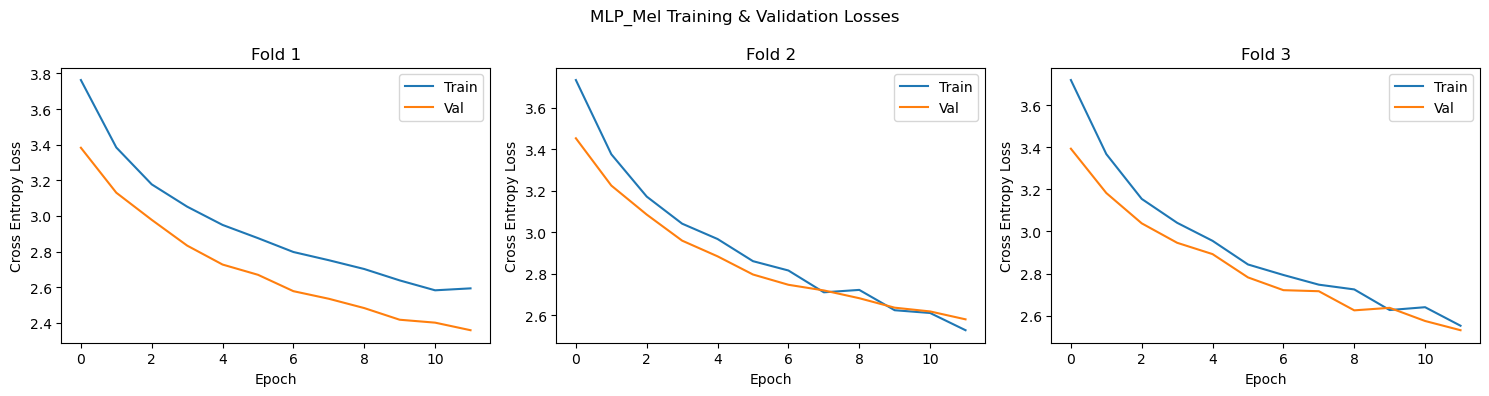

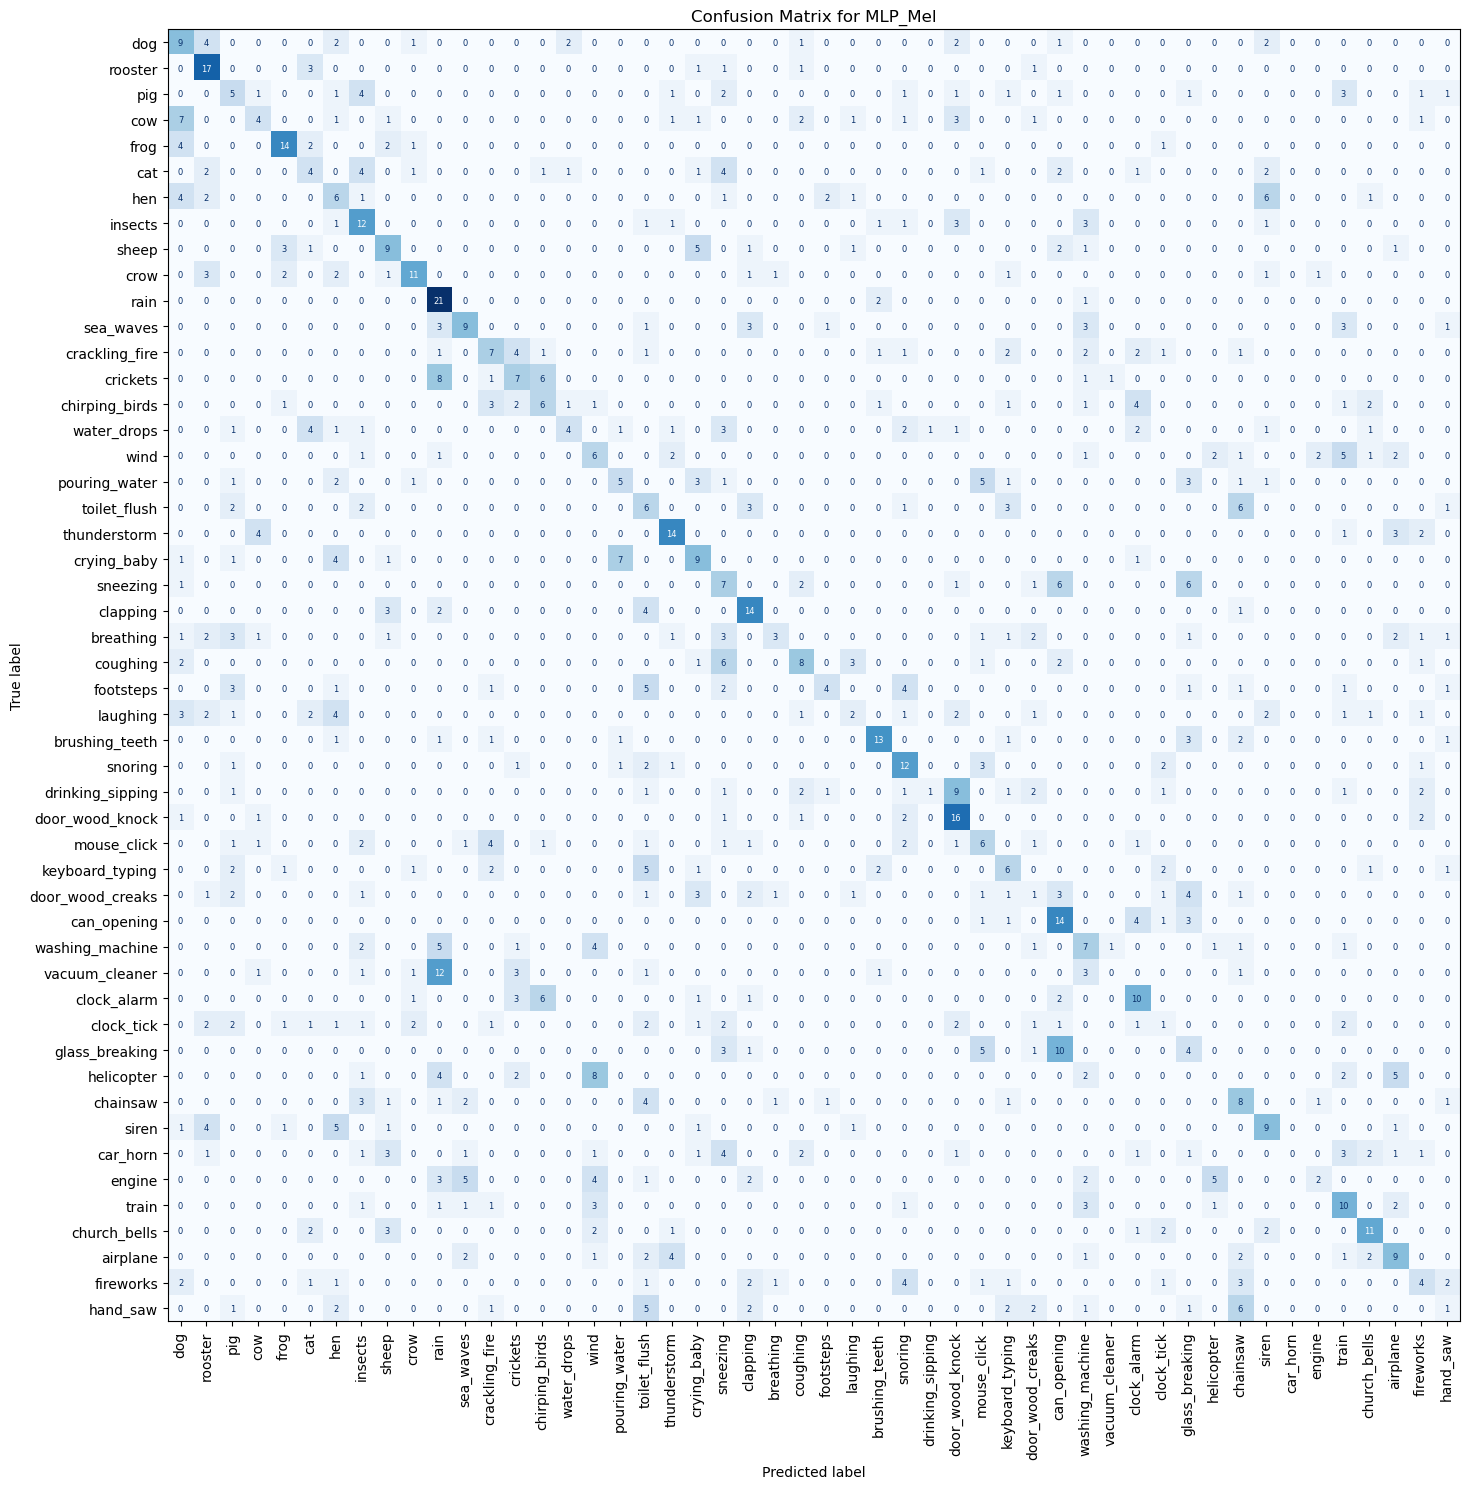

Overall Test Accuracy: 30.67%
Top 3 Classes (F1-Score):
  - frog: 0.596
  - brushing_teeth: 0.578
  - thunderstorm: 0.549
Bottom 3 Classes (F1-Score):
  - vacuum_cleaner: 0.000
  - car_horn: 0.000
  - helicopter: 0.000
Loading MEL features from cache 'mel_features_cache.npz'...

--- Training/Evaluating CNN1D ---
Fold 1/3
Fold 2/3
Fold 3/3


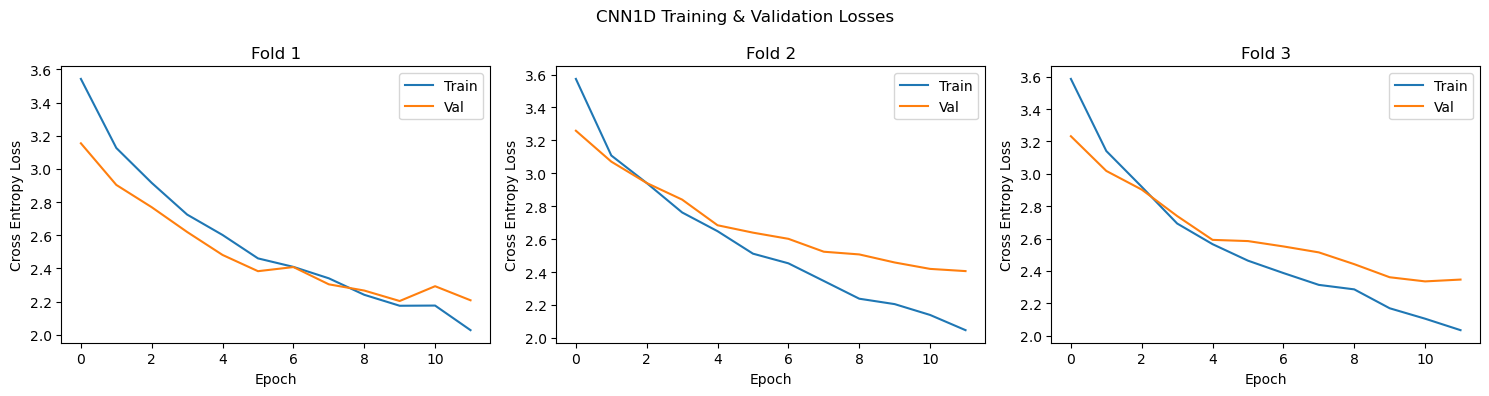

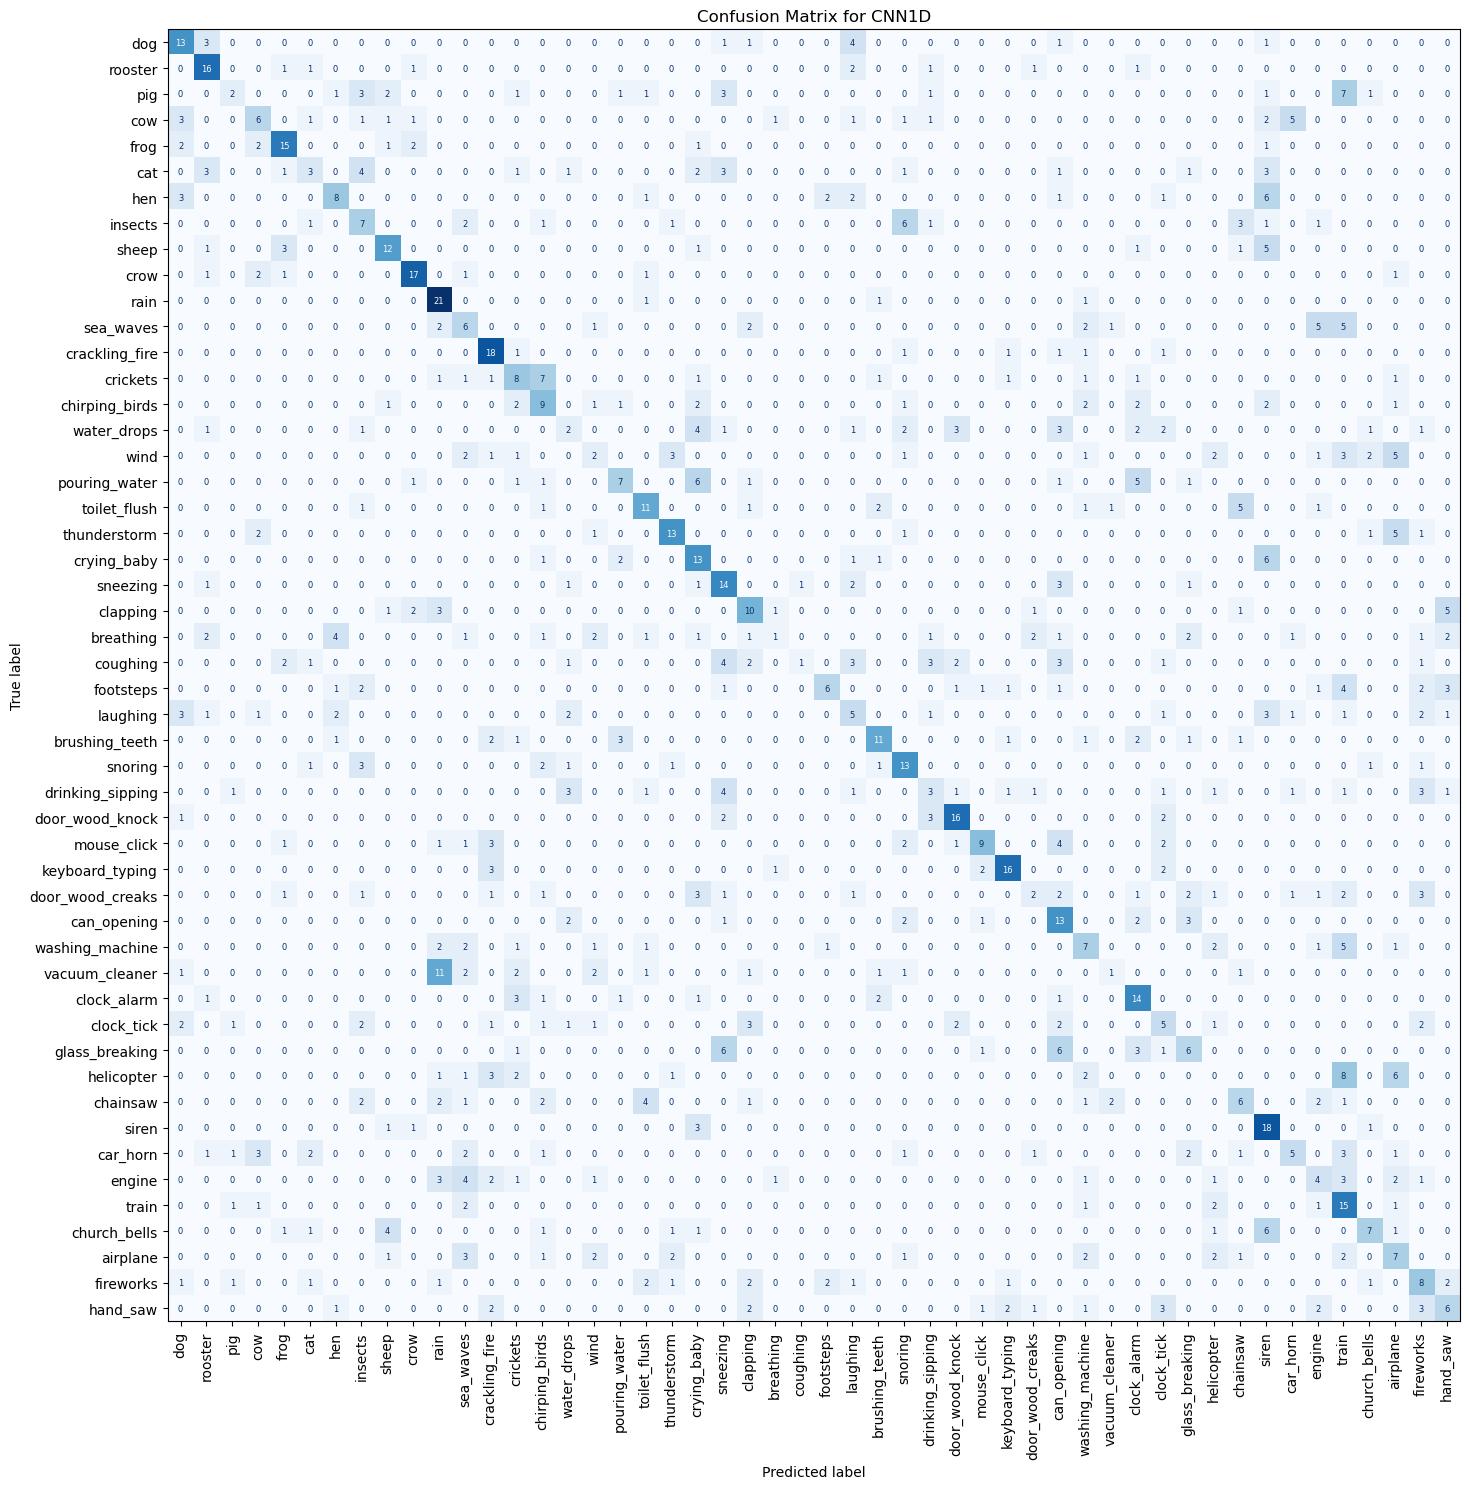

Overall Test Accuracy: 36.50%
Top 3 Classes (F1-Score):
  - crow: 0.694
  - keyboard_typing: 0.667
  - door_wood_knock: 0.640
Bottom 3 Classes (F1-Score):
  - helicopter: 0.000
  - breathing: 0.069
  - vacuum_cleaner: 0.069
Loading MEL features from cache 'mel_features_cache.npz'...

--- Training/Evaluating CNN2D ---
Fold 1/3
Fold 2/3
Fold 3/3


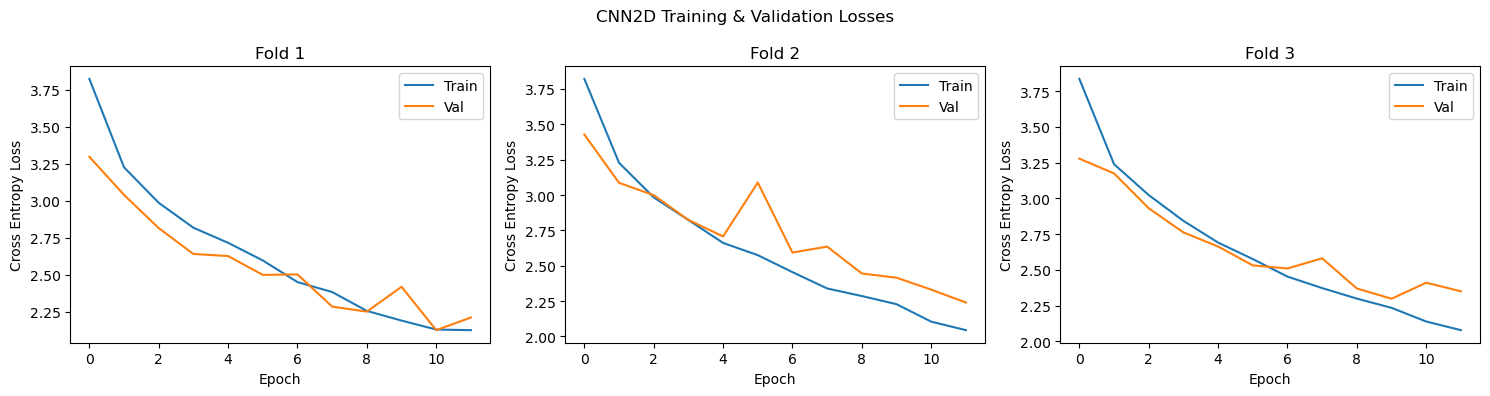

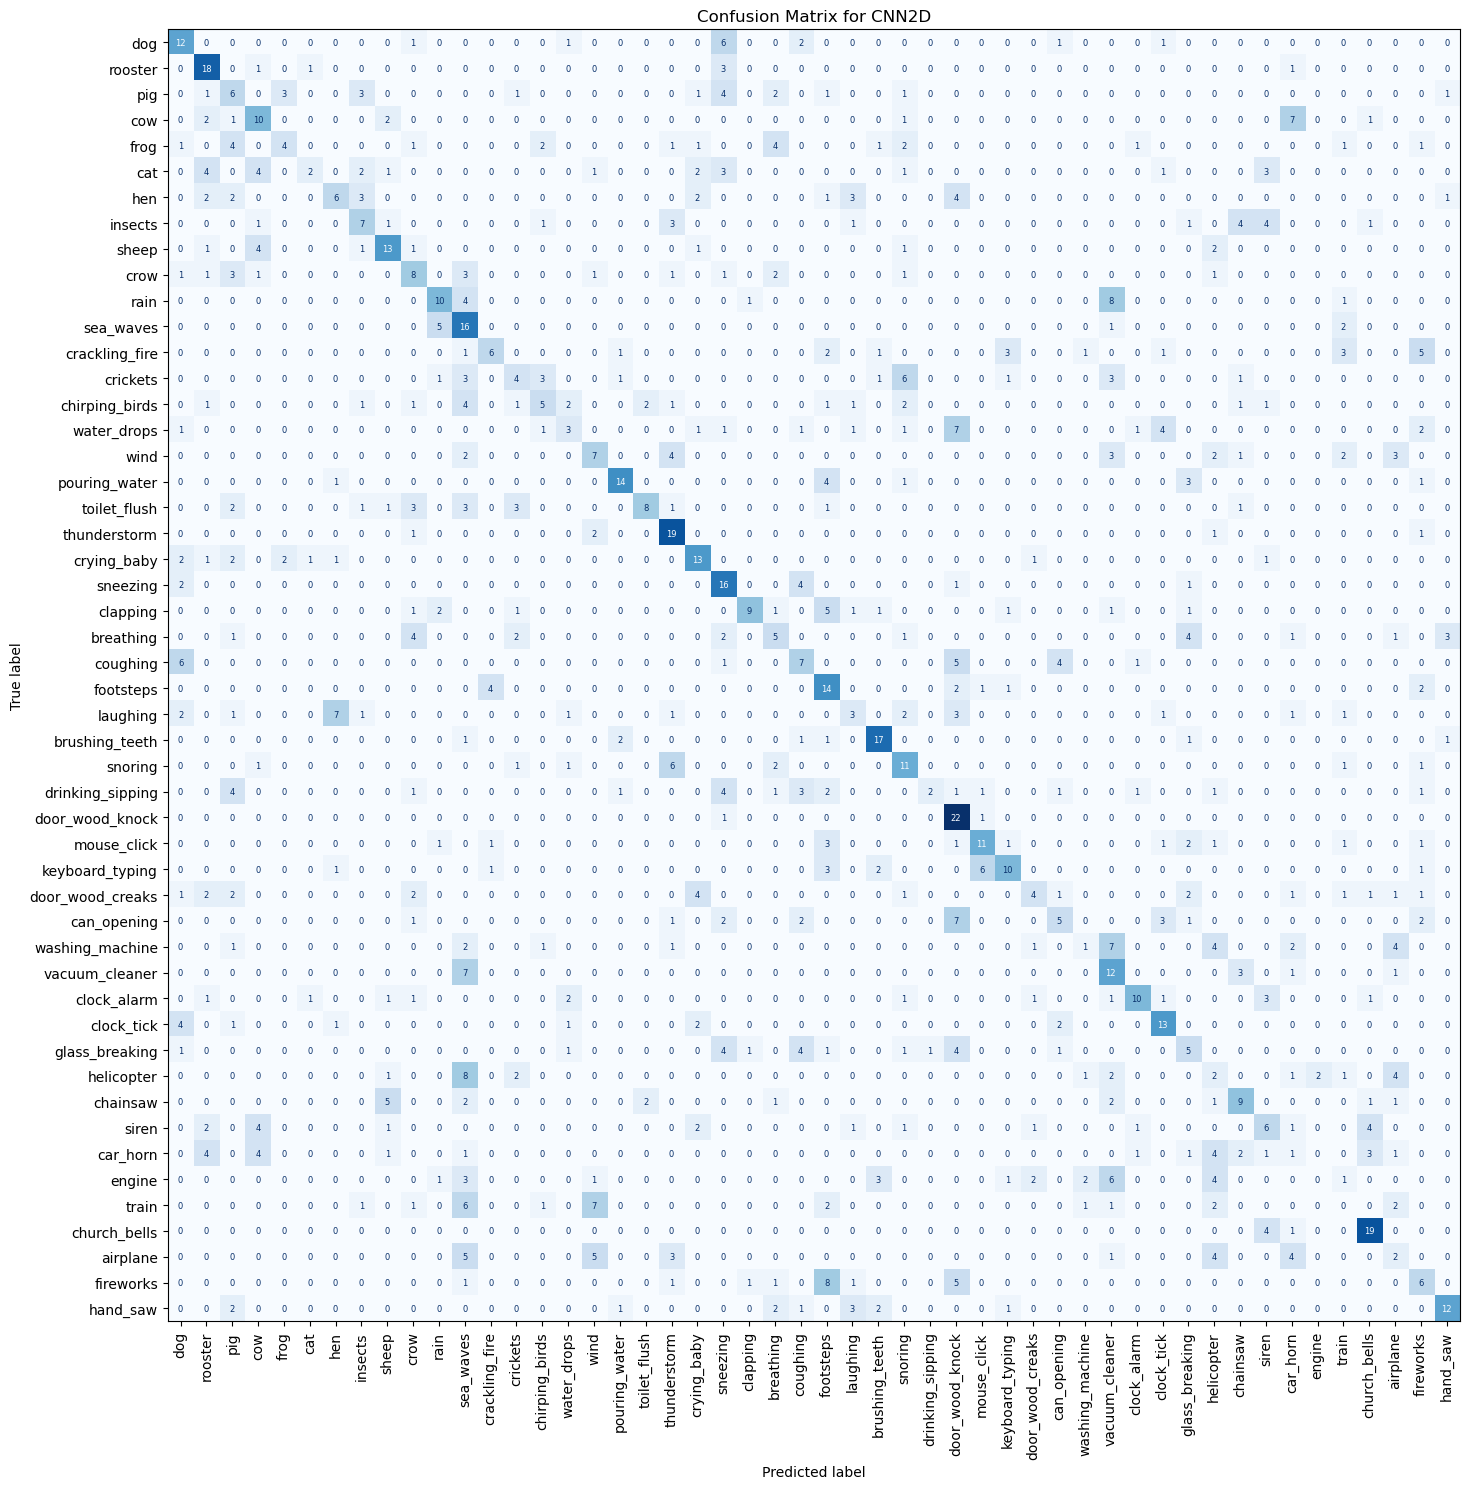

Overall Test Accuracy: 35.42%
Top 3 Classes (F1-Score):
  - church_bells: 0.691
  - brushing_teeth: 0.654
  - pouring_water: 0.636
Bottom 3 Classes (F1-Score):
  - train: 0.000
  - engine: 0.000
  - car_horn: 0.043


In [33]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Pipeline
def train_and_eval(model_cls, df, base_path, feature_type):
    # Determine the best hardware accelerator to run neural network on.
    # 'cuda' is for NVIDIA GPUs, 'mps' is for Mac Apple Silicon GPUs, and 'cpu' is standard fallback.
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
    
    # Use 3-Fold Cross-Validation splits. 
    # ([Train blocks], [Validation], [Test])
    splits = [
        ([1, 2, 3], [4], [5]),
        ([2, 3, 4], [5], [1]),
        ([3, 4, 5], [1], [2])
    ]
    
    # Load all 2,000 clips in the dataset. caches to disk.
    full_dataset = ESC50Loader(df, base_path, feature_type, device)
    
    # Arrays to accumulate raw predictions and actual labels across all 3 test folds
    all_targets = []
    all_preds = []
    
    fold_train_losses = []
    fold_val_losses = []
    
    print(f"\n--- Training/Evaluating {model_cls.__name__} ---")
    for i, (tr_folds, va_folds, te_folds) in enumerate(splits): #iterate through splits and get training, validation, test fold data from CSV
        print(f"Fold {i+1}/3")
        
        # Get the index vals for the rows belonging to train/val/test folds
        tr_idx = np.where(df['fold'].isin(tr_folds))[0]
        va_idx = np.where(df['fold'].isin(va_folds))[0]
        te_idx = np.where(df['fold'].isin(te_folds))[0]
        
        # Create subsets for specific fold using indices
        tr_ds = torch.utils.data.Subset(full_dataset, tr_idx)
        va_ds = torch.utils.data.Subset(full_dataset, va_idx)
        te_ds = torch.utils.data.Subset(full_dataset, te_idx)
        
        # DataLoaders handle taking dataset and batching it up into groups of 16 audio clips at a time
        # Shuffle training data to prevent the network from memorizing sequence order
        tr_loader = DataLoader(tr_ds, batch_size=16, shuffle=True)
        va_loader = DataLoader(va_ds, batch_size=16, shuffle=False)
        te_loader = DataLoader(te_ds, batch_size=16, shuffle=False)
        
        # Initialize a fresh copy of the model and push its weights to GPU/CPU
        model = model_cls().to(device)
        
        # The Optimizer:
        # Instead of basic SGD which applies one global learning rate, using Adam.
        # Adam adaptively speeds up/slows down the learning rate for every single parameter.
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # LR=1e-3
        
        # Cross Entropy Loss as standard mathematical penalty for Multi-Class Classification-
        crit = nn.CrossEntropyLoss()
        
        best_loss = float('inf')
        best_state = None
        
        ep_train_loss = []
        ep_val_loss = []
        
        # Training
        for ep in range(12): # Sweep over the entire dataset 12 times (epochs)
            model.train() # Switch on training-specific layers (like Dropout)
            t_loss = 0
            for X, y in tr_loader:
                X, y = X.to(device), y.to(device)
                opt.zero_grad()           # 1. Clear out old gradients from the last step
                loss = crit(model(X), y)  # 2. Forward pass: Make predictions and calculate the error (loss)
                loss.backward()           # 3. Backward pass: Calculate how much to change each weight
                opt.step()                # 4. Optimizer: Actually update the weights
                t_loss += loss.item()
            ep_train_loss.append(t_loss / len(tr_loader)) # Record average training loss for this epoch
                
            # Validation
            model.eval() # Turn off training-specific layers
            val_loss = 0
            with torch.no_grad(): # Turn off gradient descent
                for X, y in va_loader:
                    X, y = X.to(device), y.to(device)
                    val_loss += crit(model(X), y).item() # Check the error on unseen validation data
            val_loss /= len(va_loader)
            ep_val_loss.append(val_loss) # Record average validation loss for this epoch
            
            # Early Stopping Checkpoint
            # If the model hits a new lowest validation loss, store weights.
            if val_loss < best_loss: # Early Validation
                best_loss = val_loss
                best_state = {k: v.cpu() for k,v in model.state_dict().items()} # Save snapshot
        
        # Keep track of plots
        fold_train_losses.append(ep_train_loss)
        fold_val_losses.append(ep_val_loss)
        
        # Final Test Evaluation
        # Throw away the current Epoch 12 weights and reload best state
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            for X, y in te_loader: # Evaluate the totally unseen test fold
                X = X.to(device)
                # model(X) outputs 50 probabilities. argmax picks the class index with the highest probability
                preds = torch.argmax(model(X), dim=1) 
                
                # Expand global list of predictions and answers
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.numpy())
                
    # Final Metrics
    acc = accuracy_score(all_targets, all_preds)
    f1s = f1_score(all_targets, all_preds, average=None)
    
    unique_targs = df.drop_duplicates('target').sort_values('target')
    categories = unique_targs['category'].values
    
    top3 = np.argsort(f1s)[-3:][::-1]
    bot3 = np.argsort(f1s)[:3]
    
    # PLOTTING
    # 1. Plot Losses over Folds
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{model_cls.__name__} Training & Validation Losses")
    for i in range(3):
        ax[i].plot(fold_train_losses[i], label='Train')
        ax[i].plot(fold_val_losses[i], label='Val')
        ax[i].set_title(f"Fold {i+1}")
        ax[i].set_xlabel("Epoch")
        ax[i].set_ylabel("Cross Entropy Loss")
        ax[i].legend()
    plt.tight_layout()
    plt.show()
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(15, 15))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), xticks_rotation='vertical', colorbar=False)
    plt.title(f"Confusion Matrix for {model_cls.__name__}")
    for text in disp.text_.ravel():
        text.set_fontsize(6)
    plt.tight_layout()
    plt.show()
    
    print(f"Overall Test Accuracy: {acc*100:.2f}%")
    print("Top 3 Classes (F1-Score):")
    for idx in top3:
        print(f"  - {categories[idx]}: {f1s[idx]:.3f}")
    print("Bottom 3 Classes (F1-Score):")
    for idx in bot3:
        print(f"  - {categories[idx]}: {f1s[idx]:.3f}")


# ----------------------------------------------------------------------

# 1. Run Pipeline for first 3 models
esc50_df = pd.read_csv('ESC50/meta/esc50.csv')
train_and_eval(MLP_MFCC, esc50_df, 'ESC50/audio', 'mfcc')
train_and_eval(MLP_Mel, esc50_df, 'ESC50/audio', 'mel')
train_and_eval(CNN1D, esc50_df, 'ESC50/audio', 'mel')

# 2. Run Extra Credit 2D-CNN
train_and_eval(CNN2D, esc50_df, 'ESC50/audio', 'mel')

## 2: Design Choice and Results Written Response:

***In your own words:***
1. For each of the three model configurations above, briefly explain and motivate your architectural design choices.
2. Is there one model configuration that outperforms the rest significantly? Why do you think so (or if not, why not)?

## **My Reponse:**

### 1. Overview of Models:

#### MLP MFCC:
Overall Test Accuracy: 35.42%
Top 3 Classes (F1-Score):
  - rooster: 0.679
  - crying_baby: 0.652
  - clock_alarm: 0.622
Bottom 3 Classes (F1-Score):
  - vacuum_cleaner: 0.000
  - fireworks: 0.000
  - door_wood_creaks: 0.048

Design Choice & Results: To prevent the model from instantly exceeding the 200k parameter limit, the time sequence is "pooled" by taking its mean and standard deviation. This squashes the MFCCs into a tight 80-feature representation. Because this input is so small, a deep, high-capacity network (80 -> 1024 -> 100 -> 50) can be built while staying under the parameter budget. The MLP using MFCC data performed well, but the 1D-CNN outpaced it by a few percentage points. This network takes advantage of the compressed representation of audio using MFCCs, which aim to decrease the amount of redundant information. Overall, this compression appears to be useful, as the model predicts more classes more consistently. It is also worth noting that the network here takes in 40 features (then combines the mean and standard deviation of each into 80). This is a fundamentally different start point from the MLP with Mels, as that network starts with 128 features (256 once combined with mean and std) resulting in a much larger feature set.

#### MLP MELS:
Overall Test Accuracy: 31.75%
Top 3 Classes (F1-Score):
  - thunderstorm: 0.667
  - crow: 0.577
  - rooster: 0.551
Bottom 3 Classes (F1-Score):
  - drinking_sipping: 0.000
  - car_horn: 0.000
  - engine: 0.000

Design Choice & Results: Similarly to the MFCC model, temporal pooling is used to squash the sequence. However, Log-Mel features provide a larger 256-feature starting point. Because the input is larger, the initial layer connection consumes much more of the 200k budget. Therefore, a shallower and wider network (256 -> 512 -> 80 -> 50) was deliberately designed to compensate. The MLP using Mels performed the worst on average, but this is by a narrow margin that slightly changes after each training run. Overall, the process is essentially identical to the MLP with MFCC data, except it uses Mel Spectrograms which represent the raw, detailed image of the sound (with Mel scaling). It preserves almost all the harmonic shape, detailed textures, and temporal evolutions of the sound. However, the tradeoff is that the images are much larger and there are thousands of data points holding highly correlated (redundant) information. This is likely why it performed the worst.

#### 1D CNN:
Overall Test Accuracy: 38.42%
Top 3 Classes (F1-Score):
  - rooster: 0.696
  - crow: 0.642
  - clock_alarm: 0.636
Bottom 3 Classes (F1-Score):
  - breathing: 0.065
  - engine: 0.065
  - drinking_sipping: 0.074

Design Choice & Results: This model performed the best. The architecture actively stacks Conv1d and MaxPool1d layers. This is designed to specifically treat the 128 Mel bands as 128 different parallel microphones, sweeping a scanner exclusively across the time axis to find local sequence patterns. Batch Normalization and Dropout are also utilized between blocks to prevent the network from overfitting. The main strength of a 1D-CNN is its ability to learn local sequence patterns (like the sudden spike of a dog bark or the discernible flush of a toilet) by sweeping a "kernel" across the time axis frame-by-frame. In this case, a 1-dimensional time sequence is like 128 different microphones recording simultaneously for each freq band. After evaluating results, it is clear that some temporal pattern recognition is achieved: the model shows recognition of a rooster, crow, and a clock alarm with F1 Scores at ~0.6-0.7. However, the model still struggled with certain classes, and overall performance is mediocre.

#### 2D CNN:
Overall Test Accuracy: 34.92%
Top 3 Classes (F1-Score):
  - church_bells: 0.800
  - door_wood_knock: 0.772
  - footsteps: 0.694
Bottom 3 Classes (F1-Score):
  - engine: 0.000
  - glass_breaking: 0.053
  - sea_waves: 0.065

Design Choice & Results: The architecture here treats the audio as a 1-channel computer vision image. It uses 3x3 square Conv2d kernels to sweep across both time and frequency simultaneously. The channels exponentially expand (16->64->128) while spatial resolution shrinks, ultimately using an AdaptiveAvgPool2d to globally summarize the final feature map to ensure the 200k parameter budget is safely met. 2D CNNs are ideal for spatial data such as images, where filters slide in two directions to detect features, but they are more computationally intensive. In this case, the 2D CNN did not perform much better than other methods. This is likely due to the simplicity of the model and the lack of data. If a larger dataset was used and data augmentation was applied, it is likely that the network would gain a deeper understanding of the increased spectrogram data and predict classes with higher accuracy.

### 2. 

No, there is not one model configuration that outperforms the rest significantly. All four models reach comparable performance in the 30% – 38% accuracy range. The 1D-CNN model technically holds the highest accuracy (38.42%), maintaining a tiny lead of just a couple of percentage points, but this does not represent a big leap in capability.

This likely occurs due to the tiny size of the dataset. The ESC-50 dataset only provides 2,000 audio clips (just 40 clips per class). When working with a dataset this small and complex (50 distinct classes), deep learning models struggle to memorize auditory patterns.

Given the results, the 1D-CNN emerges as the strongest model overall. Its ability to sweep 1-dimensional kernels across the time axis allows it to capture temporal patterns in the audio—like a rooster’s crow or a clock alarm—more effectively than the MLPs or the 2D-CNN. Even on this small ESC-50 dataset, the 1D-CNN consistently achieves the highest accuracy (38.42%) and F1 scores across key classes. The combination of Conv1d layers, MaxPool1d, Batch Normalization, and Dropout enables the network to focus on meaningful temporal sequences while mitigating overfitting. In contrast, the MLPs rely heavily on pre-compressed features, and the 2D-CNN struggles to extract patterns efficiently from sparse data. Overall, the 1D-CNN demonstrates that treating each frequency band as a parallel “microphone” and learning local temporal features is the most effective approach for this audio classification task (although not by a substantial amount).